In [1]:
# Bayesian Inference 
# Bayes Hypothesis Test 

In [2]:
!pip install pingouin
!pip install pymc arviz


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import binom
from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency

import pingouin as pg
import pymc as pm
import arviz as az



WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
C:\Users\rasha\anaconda3\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


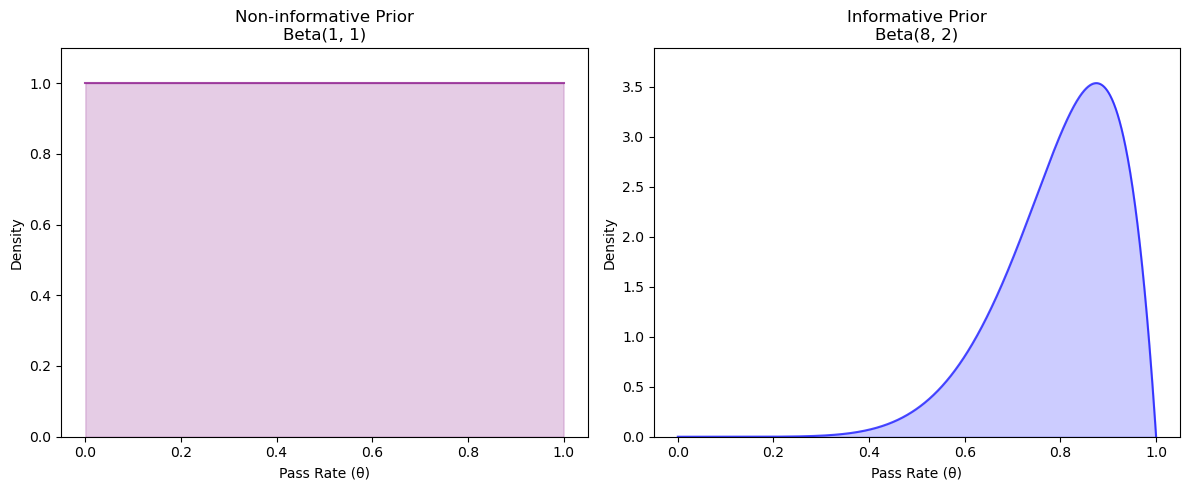

In [4]:
# The Prior P(θ), Non-informative Prior, and Informative Prior

# Set up grid for theta (pass rate) values
theta = np.linspace(0, 1, 1000)

# Non-informative prior: Beta(1, 1)
prior_noninf = beta.pdf(theta, a=1, b=1)

# Informative prior: Beta(8, 2)
prior_inf = beta.pdf(theta, a=8, b=2)

# Plot both priors
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot non-informative prior
axs[0].plot(theta, prior_noninf, color='purple', alpha=0.7)
axs[0].fill_between(theta, 0, prior_noninf, color='purple', alpha=0.2)
axs[0].set_title('Non-informative Prior\nBeta(1, 1)')
axs[0].set_xlabel('Pass Rate (θ)')
axs[0].set_ylabel('Density')
axs[0].set_ylim(0, 1.1)


# Plot informative prior
axs[1].plot(theta, prior_inf, color='blue', alpha=0.7)
axs[1].fill_between(theta, 0, prior_inf, color='blue', alpha=0.2)
axs[1].set_title('Informative Prior\nBeta(8, 2)')
axs[1].set_xlabel('Pass Rate (θ)')
axs[1].set_ylabel('Density')
axs[1].set_ylim(0, max(prior_inf)*1.1)

plt.tight_layout()
plt.show()

In [5]:
# normalize the data
# Normalizing a Discretized PDF

# 1. Discretize theta (the parameter) over [0, 1]
theta = np.linspace(0, 1, 1000)

# 2. Compute the (unnormalized) prior density at each point, e.g. Beta(8, 2)
unnormalized_prior = beta.pdf(theta, a=8, b=2)

# 3. Normalize: divide each value by the sum so the total = 1
prior_distribution = unnormalized_prior / np.sum(unnormalized_prior)

# Now, prior_distribution sums to 1
print(f"Sum after normalization: {np.sum(prior_distribution)}")


Sum after normalization: 1.0


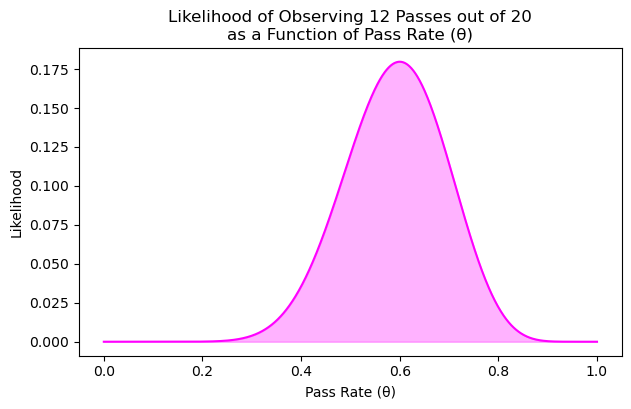

In [6]:
# Compute the Likelihood
# 1. Discretize theta
theta = np.linspace(0, 1, 1000)

# 2. Observed data: 12 passes out of 20
k = 12  # number of passes
n = 20  # total engineers

# 3. Likelihood for each value of theta
likelihood = binom.pmf(k, n, theta)

# 4. Plot the likelihood function
plt.figure(figsize=(7, 4))
plt.plot(theta, likelihood, color='magenta')
plt.fill_between(theta, 0, likelihood, color='magenta', alpha=0.3)
plt.title('Likelihood of Observing 12 Passes out of 20\nas a Function of Pass Rate (θ)')
plt.xlabel('Pass Rate (θ)')
plt.ylabel('Likelihood')
plt.show()


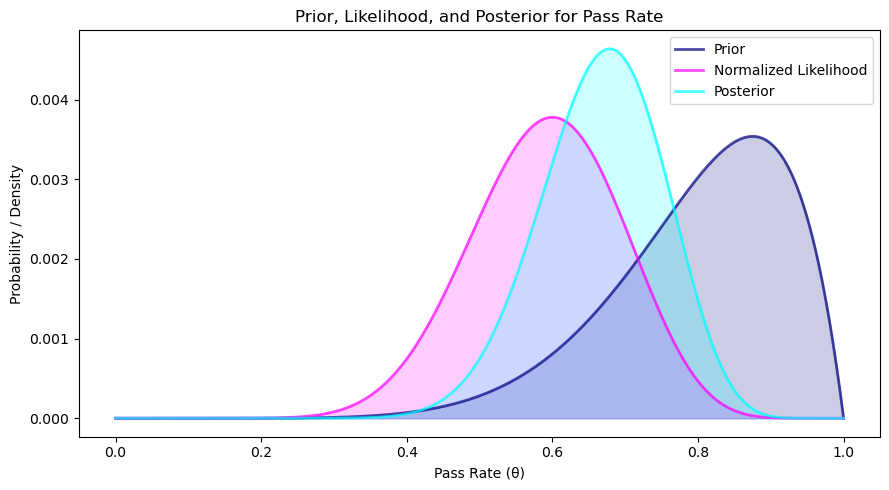

In [7]:
# Posterior Calculation and Plot
# 1. Discretize theta
theta = np.linspace(0, 1, 1000)

# 2. Prior: Informative Beta(8, 2)
prior = beta.pdf(theta, a=8, b=2)
prior /= np.sum(prior)  # normalize

# 3. Likelihood: Binomial (12 successes out of 20)
k, n = 12, 20
likelihood = binom.pmf(k, n, theta)
likelihood /= np.sum(likelihood)  # normalize for plotting

# 4. Posterior: prior * likelihood, then normalize
unnormalized_posterior = prior * likelihood
posterior = unnormalized_posterior / np.sum(unnormalized_posterior)

# 5. Overlay plot
plt.figure(figsize=(9, 5))
plt.plot(theta, prior, color='navy', lw=2, alpha=0.7, label='Prior')
plt.fill_between(theta, 0, prior, color='navy', alpha=0.2)
plt.plot(theta, likelihood, color='magenta', lw=2, alpha=0.7, label='Normalized Likelihood')
plt.fill_between(theta, 0, likelihood, color='magenta', alpha=0.2)
plt.plot(theta, posterior, color='cyan', lw=2, alpha=0.7, label='Posterior')
plt.fill_between(theta, 0, posterior, color='cyan', alpha=0.2)
plt.xlabel('Pass Rate (θ)')
plt.ylabel('Probability / Density')
plt.title('Prior, Likelihood, and Posterior for Pass Rate')
plt.legend()
plt.tight_layout()
plt.show()


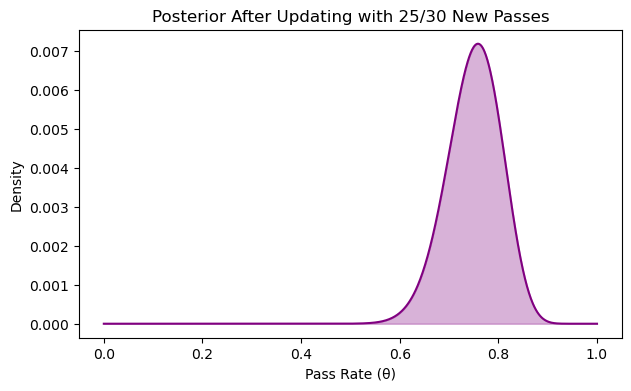

In [8]:
# Bayesian Updating Example

# 1. Theta grid and previous posterior (replace this with your posterior from the previous step)
theta = np.linspace(0, 1, 1000)
# Example: suppose you already have 'posterior' from the last update
# posterior = ... (computed earlier)

# 2. New data: 25 passes out of 30
new_k = 25
new_n = 30

# 3. Use previous posterior as new prior
new_prior = posterior

# 4. New likelihood for each theta
new_likelihood = binom.pmf(new_k, new_n, theta)

# 5. Update: prior * likelihood, then normalize
unnormalized_new_posterior = new_prior * new_likelihood
new_posterior = unnormalized_new_posterior / np.sum(unnormalized_new_posterior)

# 6. Plot new posterior
plt.figure(figsize=(7, 4))
plt.plot(theta, new_posterior, color='purple')
plt.fill_between(theta, 0, new_posterior, color='purple', alpha=0.3)
plt.xlabel('Pass Rate (θ)')
plt.ylabel('Density')
plt.title('Posterior After Updating with 25/30 New Passes')
plt.show()


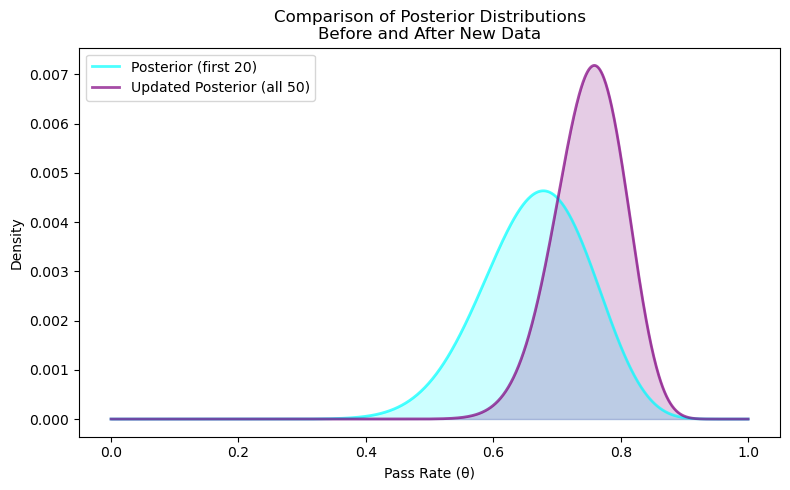

In [9]:
# Comparing Posteriors Before and After the Update

# theta: grid of pass rate values (already defined)
# posterior: previous posterior (after first update)
# new_posterior: updated posterior (after new data)

plt.figure(figsize=(8, 5))
plt.plot(theta, posterior, color='cyan', lw=2, alpha=0.7, label='Posterior (first 20)')
plt.fill_between(theta, 0, posterior, color='cyan', alpha=0.2)
plt.plot(theta, new_posterior, color='purple', lw=2, alpha=0.7, label='Updated Posterior (all 50)')
plt.fill_between(theta, 0, new_posterior, color='purple', alpha=0.2)
plt.xlabel('Pass Rate (θ)')
plt.ylabel('Density')
plt.title('Comparison of Posterior Distributions\nBefore and After New Data')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Summary Statistics of the Posterior Distribution

# Posterior mean
mean_posterior = np.sum(theta * new_posterior)

# Posterior median
cumsum = np.cumsum(new_posterior)
median_posterior = theta[np.where(cumsum >= 0.5)[0][0]]

# Posterior mode
mode_posterior = theta[np.argmax(new_posterior)]

print(f"Posterior mean:   {mean_posterior:.4f}")
print(f"Posterior median: {median_posterior:.4f}")
print(f"Posterior mode:   {mode_posterior:.4f}")


Posterior mean:   0.7500
Posterior median: 0.7528
Posterior mode:   0.7588


In [11]:
# How to Calculate a 95% Credible Interval
# Assume theta and new_posterior are as before, normalized so sum = 1

# Cumulative sum for left and right tails
cumsum = np.cumsum(new_posterior)

# Find lower bound (2.5%)
lower_idx = np.where(cumsum >= 0.025)[0][0]
lower_bound = theta[lower_idx]

# Find upper bound (97.5%)
upper_idx = np.where(cumsum >= 0.975)[0][0]
upper_bound = theta[upper_idx]

print(f"95% credible interval: [{lower_bound:.3f}, {upper_bound:.3f}]")


95% credible interval: [0.634, 0.850]


In [12]:
## Bayes Hypothesis Test ##
# Bayesian t-test to compare the mean sales between the two performance groups. 
#  Null Hypothesis: there is no difference in mean sales between high and low performing salespeople, 
# Alternative Hypothesis there is a difference in mean sales between the two groups. 

In [13]:
# Load local CSV
salespeople = pd.read_csv("salespeople.csv")

# Remove missing values
salespeople = salespeople.dropna()

# Reproducibility
np.random.seed(42)

# Sample 10 from performance = 1
low_perf = salespeople[salespeople["performance"] == 1]
sample_low = low_perf.sample(n=10, random_state=42)

# Sample 10 from performance = 4
high_perf = salespeople[salespeople["performance"] == 4]
sample_high = high_perf.sample(n=10, random_state=42)

# Combine
df_sales = pd.concat([sample_low, sample_high])


In [14]:
# Classical Independent t-test
# Frequentist result
low_sales = sample_low["sales"]
high_sales = sample_high["sales"]

t_stat, p_value = ttest_ind(low_sales, high_sales, equal_var=True)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -2.65077602120399
p-value: 0.016262189247879196


In [15]:
# Bayesian t-test (Bayes Factor)
bf_results = pg.ttest(high_sales, low_sales, paired=False)

bf_results


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.650776,18,two-sided,0.016262,"[40.91, 353.49]",1.185463,3.661,0.707963


In [16]:
# run Bayesian t-test and simulate posterior samples over 10000 points
# Extract the two groups
low_sales = sample_low["sales"].values
high_sales = sample_high["sales"].values


In [17]:
# Bayesian Two-Sample Model
# use weakly informative priors

with pm.Model() as model:

    # Priors for group means
    mu_low  = pm.Normal("mu_low",  mu=0, sigma=1000)
    mu_high = pm.Normal("mu_high", mu=0, sigma=1000)

    # Shared standard deviation
    sigma = pm.HalfNormal("sigma", sigma=1000)

    # Likelihood
    obs_low  = pm.Normal("obs_low",  mu=mu_low,  sigma=sigma, observed=low_sales)
    obs_high = pm.Normal("obs_high", mu=mu_high, sigma=sigma, observed=high_sales)

    # Difference in means
    delta = pm.Deterministic("delta", mu_high - mu_low)

    trace = pm.sample(2000, tune=2000, return_inferencedata=True, random_seed=42)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_low, mu_high, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 287 seconds.


In [18]:
# Posterior Summary
az.summary(trace, var_names=["delta"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta,195.553,80.065,45.34,348.424,0.947,1.033,7305.0,5510.0,1.0


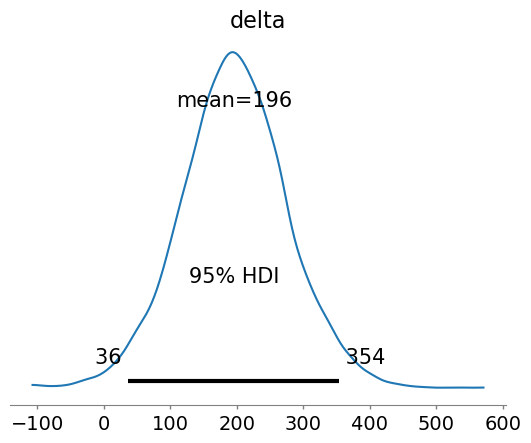

In [19]:
# Plot Posterior
az.plot_posterior(trace, var_names=["delta"], hdi_prob=0.95)
plt.show()


In [20]:
# posterior probability that high performers truly outsell low performers
np.mean(trace.posterior["delta"].values > 0)


np.float64(0.990875)

In [21]:
# Bayesian test for non-zero correlation
# Is there a non-zero correlation between sales and average customer rating.

In [22]:
# Bayesian test for non-zero correlation
salespeople = pd.read_csv("salespeople.csv").dropna()

np.random.seed(42)
sample_salespeople = salespeople.sample(n=10)

x = sample_salespeople["sales"]
y = sample_salespeople["customer_rate"]


In [23]:
# Frequentist Correlation (Baseline)
r, p_value = pearsonr(x, y)

print("Correlation:", r)
print("p-value:", p_value)


Correlation: 0.7229852022385175
p-value: 0.018148021869979845


In [24]:
# Bayesian Correlation (Bayes Factor)
bf_corr = pg.bayesfactor_pearson(r, n=len(x))

print("Bayes Factor BF10:", bf_corr)


Bayes Factor BF10: 4.476995554070037


In [25]:
# Bayesian chi-square test
# Test for difference in frequency distribution between groups

# Is there is a difference in likelihood of promotion between the performance categories of salespeople. 

In [26]:
# Frequentist Baseline
# Build the contingency table

# Load data
salespeople = pd.read_csv("salespeople.csv")
salespeople = salespeople.dropna()

# Sample 20 from each performance group
np.random.seed(42)

sample_data = pd.DataFrame()

for i in range(1, 5):
    perf_group = salespeople[salespeople["performance"] == i]
    sample_group = perf_group.sample(20, random_state=42)
    sample_data = pd.concat([sample_data, sample_group])

# Create contingency table
contingency = pd.crosstab(sample_data["promoted"],
                          sample_data["performance"])

contingency


performance,1.0,2.0,3.0,4.0
promoted,,,,
0,15,19,13,5
1,5,1,7,15


In [27]:
# Classical Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("p-value:", p_value)


Chi-square: 22.857142857142858
p-value: 4.32485729829276e-05


In [28]:
## data exercises

In [32]:
# load exam scores data
exam = pd.read_csv("ugtests.csv").dropna()
exam.head()

,Yr1,Yr2,Yr3,Final
0,27,50,52,93
1,70,104,126,207
2,27,36,148,175
3,26,75,115,125
4,46,77,75,114


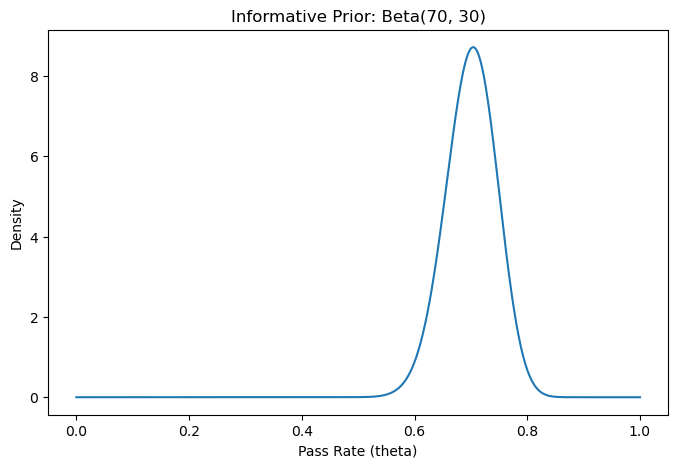

In [33]:
# Prior parameters
alpha_prior = 70
beta_prior = 30

# Grid of theta values
theta = np.linspace(0, 1, 1000)

# Beta prior density
prior_density = beta.pdf(theta, alpha_prior, beta_prior)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(theta, prior_density)
plt.title("Informative Prior: Beta(70, 30)")
plt.xlabel("Pass Rate (theta)")
plt.ylabel("Density")
plt.show()

In [34]:
# define pass indicator for Year 1
exam["pass"] = (exam["Yr1"] >= 40).astype(int)

# quick check
exam[["Yr1", "pass"]].head()

,Yr1,pass
0,27,0
1,70,1
2,27,0
3,26,0
4,46,1


In [35]:
# sample 20

np.random.seed(42)

# first sample of 20 students
sample1 = exam.sample(n=20, replace=False)

sample1.head()

,Yr1,Yr2,Yr3,Final,pass
199,76,137,97,139,1
789,61,75,123,145,1
174,50,37,80,41,1
467,53,187,75,108,1
66,55,110,106,133,1


In [36]:
# compute the observed data summary for the likelihood.
n1 = len(sample1)
y1 = sample1["pass"].sum()

print("Sample size (n1):", n1)
print("Number of passes (y1):", y1)
print("Observed pass rate:", y1 / n1)

Sample size (n1): 20
Number of passes (y1): 14
Observed pass rate: 0.7


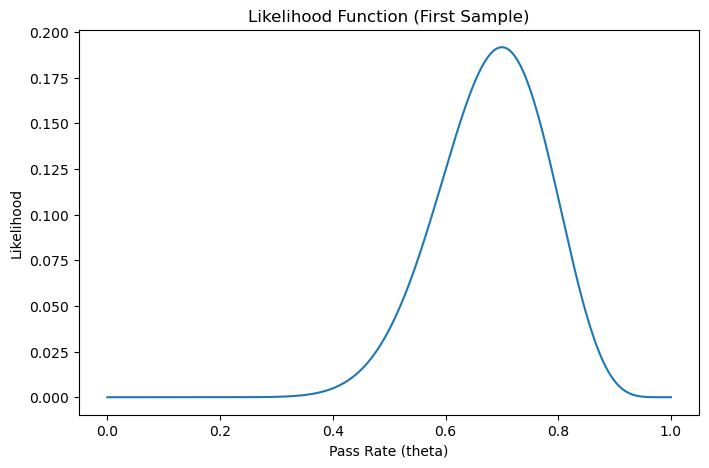

In [37]:
theta = np.linspace(0, 1, 1000)

# likelihood values (binomial pmf evaluated at y1 for varying theta)
likelihood = binom.pmf(y1, n1, theta)

plt.figure(figsize=(8,5))
plt.plot(theta, likelihood)
plt.title("Likelihood Function (First Sample)")
plt.xlabel("Pass Rate (theta)")
plt.ylabel("Likelihood")
plt.show()

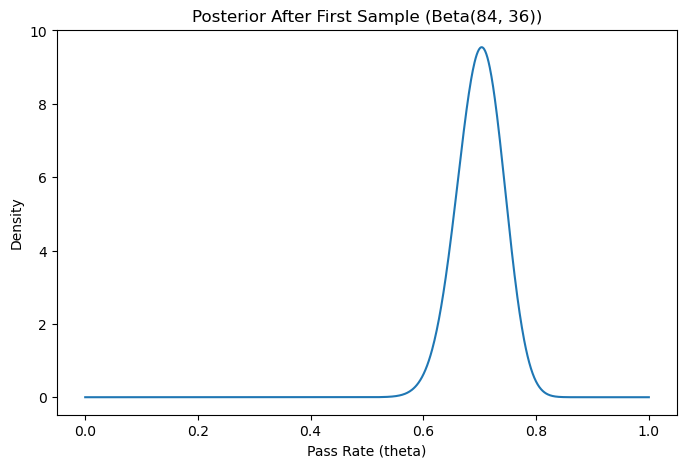

In [38]:
# posterior 

# Posterior parameters
alpha_post1 = 84
beta_post1 = 36

theta = np.linspace(0, 1, 1000)
posterior1 = beta.pdf(theta, alpha_post1, beta_post1)

plt.figure(figsize=(8,5))
plt.plot(theta, posterior1)
plt.title("Posterior After First Sample (Beta(84, 36))")
plt.xlabel("Pass Rate (theta)")
plt.ylabel("Density")
plt.show()

In [39]:
# remove first sample from full dataset
remaining = exam.drop(sample1.index)

len(remaining)

955

In [40]:
np.random.seed(42)

sample2 = remaining.sample(n=30, replace=False)

sample2.head()

,Yr1,Yr2,Yr3,Final,pass
205,55,87,138,171,1
430,40,117,61,134,1
709,44,146,98,137,1
766,52,55,145,149,1
396,58,110,95,123,1


In [41]:
# compute the summary for the second sample.
n2 = len(sample2)
y2 = sample2["pass"].sum()

print("Sample size (n2):", n2)
print("Number of passes (y2):", y2)
print("Observed pass rate (sample2):", y2 / n2)

Sample size (n2): 30
Number of passes (y2): 25
Observed pass rate (sample2): 0.8333333333333334


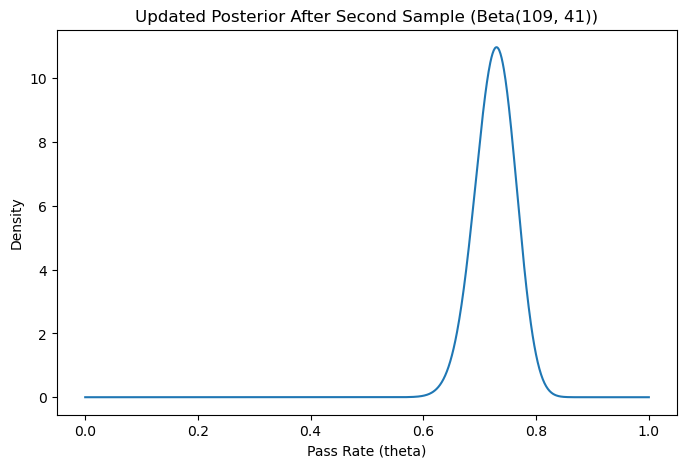

In [42]:
alpha_post2 = 109
beta_post2 = 41

theta = np.linspace(0, 1, 1000)
posterior2 = beta.pdf(theta, alpha_post2, beta_post2)

plt.figure(figsize=(8,5))
plt.plot(theta, posterior2)
plt.title("Updated Posterior After Second Sample (Beta(109, 41))")
plt.xlabel("Pass Rate (theta)")
plt.ylabel("Density")
plt.show()

In [43]:
alpha_post2 = 109
beta_post2 = 41

# Mean
mean_post = alpha_post2 / (alpha_post2 + beta_post2)

# Median (numerical)
median_post = beta.median(alpha_post2, beta_post2)

# Mode (since alpha, beta > 1)
mode_post = (alpha_post2 - 1) / (alpha_post2 + beta_post2 - 2)

# 95% credible interval
ci_lower, ci_upper = beta.ppf([0.025, 0.975], alpha_post2, beta_post2)

print("Posterior Mean:", mean_post)
print("Posterior Median:", median_post)
print("Posterior Mode:", mode_post)
print("95% Credible Interval:", (ci_lower, ci_upper))

Posterior Mean: 0.7266666666666667
Posterior Median: 0.7276763325921871
Posterior Mode: 0.7297297297297297
95% Credible Interval: (np.float64(0.6528639248724696), np.float64(0.7947452824061355))


In [1]:
# Setup & Data Preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data
exam = pd.read_csv("ugtests.csv").dropna()
exam.head()

# Focus on Year 1, create pass/fail column
exam['pass'] = (exam['Yr1'] >= 40).astype(int)

# Sample 1: 20 students
np.random.seed(42)
sample1 = exam.sample(n=20)
remaining = exam.drop(sample1.index)

# Sample 2: 30 students from remaining
sample2 = remaining.sample(n=30)

print(f"Sample 1: {sample1['pass'].sum()} passes out of 20")
print(f"Sample 2: {sample2['pass'].sum()} passes out of 30")


Sample 1: 14 passes out of 20
Sample 2: 28 passes out of 30


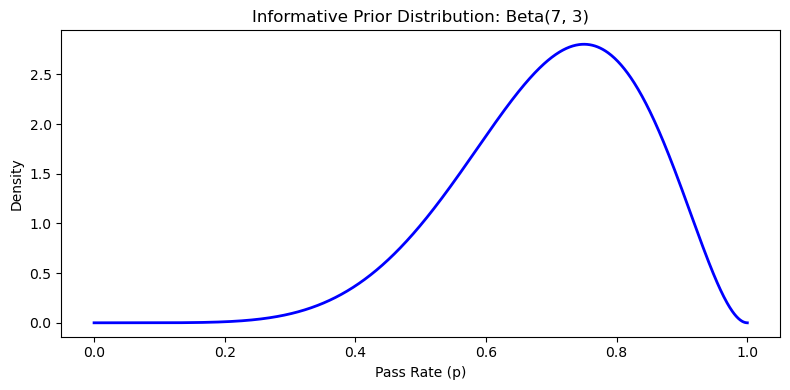

In [2]:
# Question 1 — Informative Prior

# Prior belief: ~7 in 10 students pass
# Beta(7, 3) -> mean = 0.7
alpha_prior = 7
beta_prior = 3

p_seq = np.linspace(0, 1, 1000)
prior_density = stats.beta.pdf(p_seq, alpha_prior, beta_prior)

plt.figure(figsize=(8, 4))
plt.plot(p_seq, prior_density, color='blue', linewidth=2)
plt.title('Informative Prior Distribution: Beta(7, 3)')
plt.xlabel('Pass Rate (p)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()



Sample 1: 14 passes out of 20


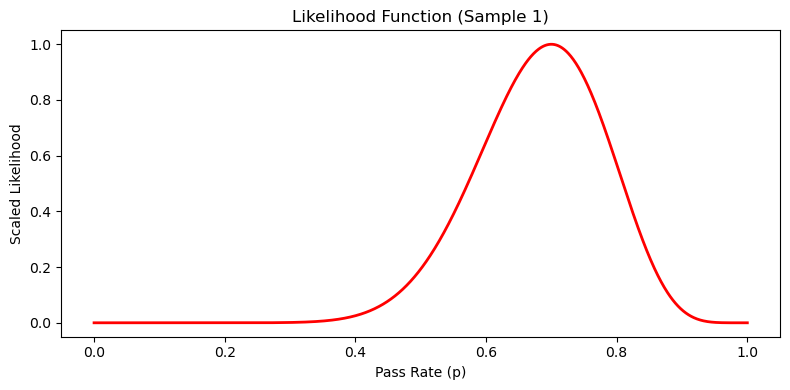

In [3]:
# Question 2 — Likelihood Function

n1 = len(sample1)
k1 = sample1['pass'].sum()

likelihood = stats.binom.pmf(k1, n=n1, p=p_seq)
likelihood_norm = likelihood / likelihood.max()

print(f"Sample 1: {k1} passes out of {n1}")

plt.figure(figsize=(8, 4))
plt.plot(p_seq, likelihood_norm, color='red', linewidth=2)
plt.title('Likelihood Function (Sample 1)')
plt.xlabel('Pass Rate (p)')
plt.ylabel('Scaled Likelihood')
plt.tight_layout()
plt.show()



Posterior 1: Beta(21, 9)


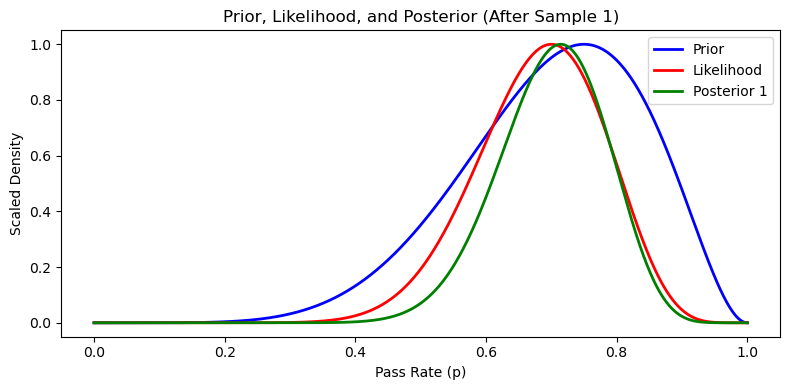

In [4]:
# Question 3 — Posterior Distribution (After Sample 1)

# Beta-Binomial conjugate update:
# Posterior = Beta(alpha_prior + k, beta_prior + n - k)
alpha_post1 = alpha_prior + k1
beta_post1  = beta_prior + (n1 - k1)

posterior1_density = stats.beta.pdf(p_seq, alpha_post1, beta_post1)

print(f"Posterior 1: Beta({alpha_post1}, {beta_post1})")

# Standardize all three for comparison
prior_norm     = prior_density / prior_density.max()
posterior1_norm = posterior1_density / posterior1_density.max()

plt.figure(figsize=(8, 4))
plt.plot(p_seq, prior_norm,      color='blue',  linewidth=2, label='Prior')
plt.plot(p_seq, likelihood_norm, color='red',   linewidth=2, label='Likelihood')
plt.plot(p_seq, posterior1_norm, color='green', linewidth=2, label='Posterior 1')
plt.title('Prior, Likelihood, and Posterior (After Sample 1)')
plt.xlabel('Pass Rate (p)')
plt.ylabel('Scaled Density')
plt.legend()
plt.tight_layout()
plt.show()



Sample 2: 28 passes out of 30
Posterior 2: Beta(49, 11)


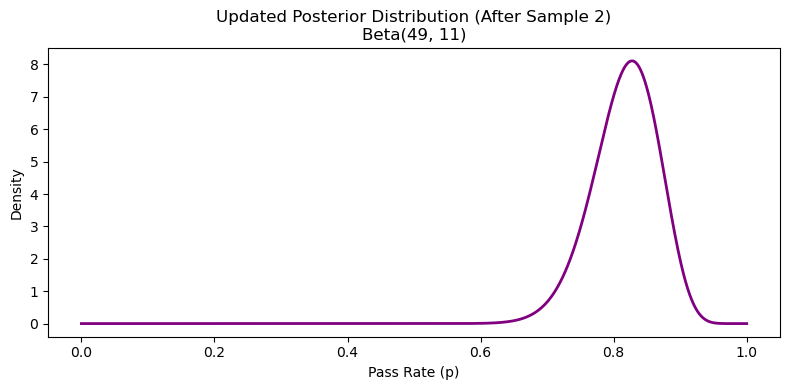

In [5]:
# Question 4 — Bayesian Updating with Sample 2

n2 = len(sample2)
k2 = sample2['pass'].sum()

alpha_post2 = alpha_post1 + k2
beta_post2  = beta_post1  + (n2 - k2)

posterior2_density = stats.beta.pdf(p_seq, alpha_post2, beta_post2)

print(f"Sample 2: {k2} passes out of {n2}")
print(f"Posterior 2: Beta({alpha_post2}, {beta_post2})")

plt.figure(figsize=(8, 4))
plt.plot(p_seq, posterior2_density, color='purple', linewidth=2)
plt.title(f'Updated Posterior Distribution (After Sample 2)\nBeta({alpha_post2}, {beta_post2})')
plt.xlabel('Pass Rate (p)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()



In [6]:
# Question 5 — Summary Statistics & 95% Credible Interval

post2_mean   = alpha_post2 / (alpha_post2 + beta_post2)
post2_median = stats.beta.ppf(0.5,   alpha_post2, beta_post2)
post2_mode   = (alpha_post2 - 1) / (alpha_post2 + beta_post2 - 2)

ci_lower = stats.beta.ppf(0.025, alpha_post2, beta_post2)
ci_upper = stats.beta.ppf(0.975, alpha_post2, beta_post2)

print(f"Mean:   {post2_mean:.4f}")
print(f"Median: {post2_median:.4f}")
print(f"Mode:   {post2_mode:.4f}")
print(f"95% Credible Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

Mean:   0.8167
Median: 0.8202
Mode:   0.8276
95% Credible Interval: [0.7103, 0.9031]


In [7]:
# define quartiles based on Year 1
q1 = exam["Yr1"].quantile(0.25)
q3 = exam["Yr1"].quantile(0.75)

# bottom and top quartiles
bottom = exam[exam["Yr1"] <= q1]
top = exam[exam["Yr1"] >= q3]

# sample 50 total observations
np.random.seed(42)
sample_q = exam.sample(n=50, replace=False)

# split into groups
bottom_group = sample_q[sample_q["Yr1"] <= q1]["Yr2"]
top_group = sample_q[sample_q["Yr1"] >= q3]["Yr2"]

print(len(bottom_group), len(top_group))

13 17


In [8]:
import pingouin as pg

bf_results = pg.ttest(top_group, bottom_group, paired=False)

bf_results

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.602643,23.816856,two-sided,0.552442,"[-17.7, 32.28]",0.226494,0.398,0.091287


In [9]:
import pymc as pm
import arviz as az
import numpy as np

# convert to numpy
y_top = top_group.values
y_bottom = bottom_group.values

with pm.Model() as model:
    # priors
    mu_top = pm.Normal("mu_top", mu=0, sigma=100)
    mu_bottom = pm.Normal("mu_bottom", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=50)

    # likelihood
    top_obs = pm.Normal("top_obs", mu=mu_top, sigma=sigma, observed=y_top)
    bottom_obs = pm.Normal("bottom_obs", mu=mu_bottom, sigma=sigma, observed=y_bottom)

    # difference
    delta = pm.Deterministic("delta", mu_top - mu_bottom)

    # sampling
    trace = pm.sample(2000, tune=2000, return_inferencedata=True)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
C:\Users\rasha\anaconda3\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_top, mu_bottom, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 237 seconds.


<Axes: title={'center': 'delta'}>

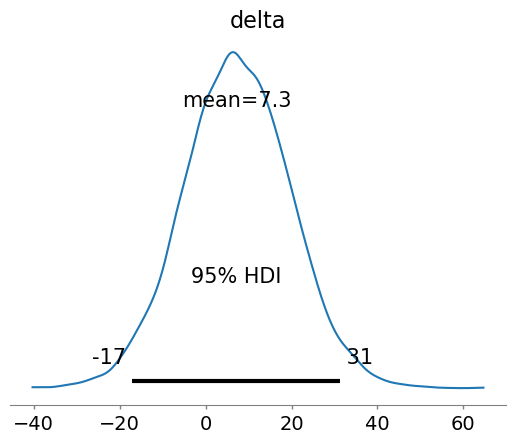

In [10]:
az.plot_posterior(trace, var_names=["delta"], hdi_prob=0.95)

In [11]:
np.mean(trace.posterior["delta"].values > 0)

np.float64(0.723375)

In [12]:
from scipy.stats import pearsonr
import pingouin as pg

x = sample_q["Yr2"]
y = sample_q["Final"]

# Frequentist correlation
r, p_value = pearsonr(x, y)

# Bayes Factor for correlation
bf_corr = pg.bayesfactor_pearson(r, n=len(sample_q))

print("Correlation (r):", r)
print("p-value:", p_value)
print("Bayes Factor BF10:", bf_corr)

Correlation (r): 0.28221287656884275
p-value: 0.04707347525360918
Bayes Factor BF10: 1.1979288135753638


In [13]:
import pymc as pm
import arviz as az
import numpy as np

x = sample_q["Yr2"].values
y = sample_q["Final"].values

# standardize
x_std = (x - x.mean()) / x.std()
y_std = (y - y.mean()) / y.std()

with pm.Model() as corr_model:
    rho = pm.Uniform("rho", lower=-1, upper=1)
    sigma = pm.HalfNormal("sigma", 1)

    mu = rho * x_std
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_std)

    trace_corr = pm.sample(2000, tune=2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 268 seconds.


<Axes: title={'center': 'rho'}>

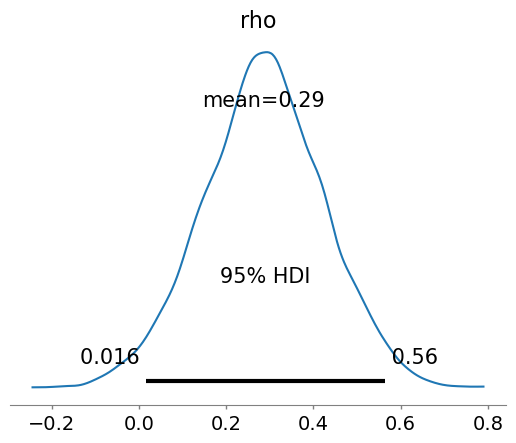

In [14]:
az.plot_posterior(trace_corr, var_names=["rho"], hdi_prob=0.95)